# GABLS1 LES Intercomparison Study for Stable Boundary Layers: Structure Functions with $S_2(r)/u_{scale}^2 = A + B\,\ln(r/r_0)$ Fit

*Last updated: June 2026*

For case setup and physical parameters, see the [Description](SBL_GABLS1_Description.ipynb) notebook.

Second-order longitudinal structure functions $S_2(r) = \langle |f(x+r) - f(x)|^2 \rangle$ of $u$ and $\theta$ are fitted to the log-scaling model. In dimensionless form:
$$\frac{S_2(r)}{u_\mathrm{scale}^2} = A + B\,\log(r/r_0)$$
which, expanding $\log(r/r_0) = \log r - \log r_0$ and absorbing constants, gives the equivalent dimensional form actually fitted to the data:
$$S_2(r) = A_* + B_*\,\log(r)$$
where $A_* = u_\mathrm{scale}^2(A - B\log r_0)$ and $B_* = u_\mathrm{scale}^2\,B$ are estimated directly by linear regression of $S_2$ on $\log r$. The fit range $[r_\mathrm{lo},\, r_\mathrm{hi}]$ is prescribed manually per height level. Reference run: `256x256x256_LASDD_SM_DP` at $t = 9$ h.

## Setup

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Output directory

In [100]:
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate JAXALFA0.1 repository root')

BaseDir   = find_repo_root()
RunDir    = BaseDir / 'examples/SBL_GABLS1/runs/256x256x256_LASDD_SM_DP'
OutputDir = RunDir / 'output'

cfg = {}
exec((RunDir / 'Config.py').read_text(), cfg)

### Load 3D fields at $t = 9$ h

In [101]:
T_snapshot = 9 * 3600
dt         = float(cfg['dt'])
iter_3D    = int(T_snapshot / dt)
field_path = OutputDir / f'ALFA_3DFields_Iteration_{iter_3D}.npz'

nx = int(cfg['nx']); ny = int(cfg['ny']); nz = int(cfg['nz'])

if field_path.exists():
    File3D = np.load(field_path)
    u3D    = File3D['u']
    TH3D   = File3D['TH']
    print(f'Loaded {field_path.name}  shape: {u3D.shape}')
else:
    print(f'Missing {field_path}; using NaN placeholders.')
    u3D  = np.full((nx, ny, nz), np.nan)
    TH3D = np.full((nx, ny, nz), np.nan)

Loaded ALFA_3DFields_Iteration_648000.npz  shape: (256, 256, 256)


### Grid parameters

In [102]:
l_x = float(cfg['l_x'])
l_z = float(cfg['l_z'])
dx  = l_x / nx

z_u      = np.array([(k + 0.5) * l_z / (nz - 1) for k in range(nz)])
k_levels = [int(nz / 32), int(nz / 16), int(nz / 8), int(nz / 4)]
z_labels = [f'{z_u[k]:.1f}' for k in k_levels]

print('Height levels (k, z):')
for k, zl in zip(k_levels, z_labels):
    print(f'  k={k:4d}  z={zl} m')
print(f'dx = {dx:.4f} m')

Height levels (k, z):
  k=   8  z=13.3 m
  k=  16  z=25.9 m
  k=  32  z=51.0 m
  k=  64  z=101.2 m
dx = 1.5625 m


### Structure function and adaptive ln(r) fit

In [103]:
def StructureFunction1D_LES(X, max_r=None):
    """Second-order longitudinal structure function along axis 0, averaged over axis 1."""
    NI, NJ = X.shape
    if max_r is None:
        max_r = NI - 1
    max_r = min(max_r, NI - 1)
    S = np.zeros((3, max_r))
    for r in range(1, max_r + 1):
        d = np.abs(X[r:, :] - X[:NI - r, :])
        S[0, r - 1] = d.mean()
        S[1, r - 1] = (d ** 2).mean()
        S[2, r - 1] = (d ** 3).mean()
    rr = np.arange(1, max_r + 1)
    return S, rr


def fit_lnr(r_m, S2, r_lo, r_hi):
    """Fit S2 = A* + B* * ln(r) over the prescribed range [r_lo, r_hi].

    Parameters
    ----------
    r_m        : 1-D array of all separations (m)
    S2         : 1-D array of second-order structure function values
    r_lo, r_hi : fit range endpoints (m)

    Returns
    -------
    Bstar, Astar : slope and intercept of S2 = Astar + Bstar * ln(r)
    R2           : coefficient of determination over the fit range
    mask         : boolean array (same length as r_m) marking the fit range
    """
    mask   = (r_m >= r_lo) & (r_m <= r_hi)
    ln_r   = np.log(r_m[mask])
    S_sub  = S2[mask]
    Bstar, Astar = np.polyfit(ln_r, S_sub, 1)
    S_fit  = Bstar * ln_r + Astar
    ss_res = np.sum((S_sub - S_fit) ** 2)
    ss_tot = np.sum((S_sub - S_sub.mean()) ** 2)
    R2     = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 0.0
    return Bstar, Astar, R2, mask

In [104]:
plt.rcParams.update({
    'text.usetex': True,
    'font.size': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

## Structure Functions of $u$

u  z=13.3   m: B*=0.1791, A*=-0.2337, R2=0.9960
u  z=25.9   m: B*=0.1919, A*=-0.3081, R2=0.9989
u  z=51.0   m: B*=0.1165, A*=-0.1687, R2=0.9946
u  z=101.2  m: B*=0.0888, A*=-0.1553, R2=0.9983


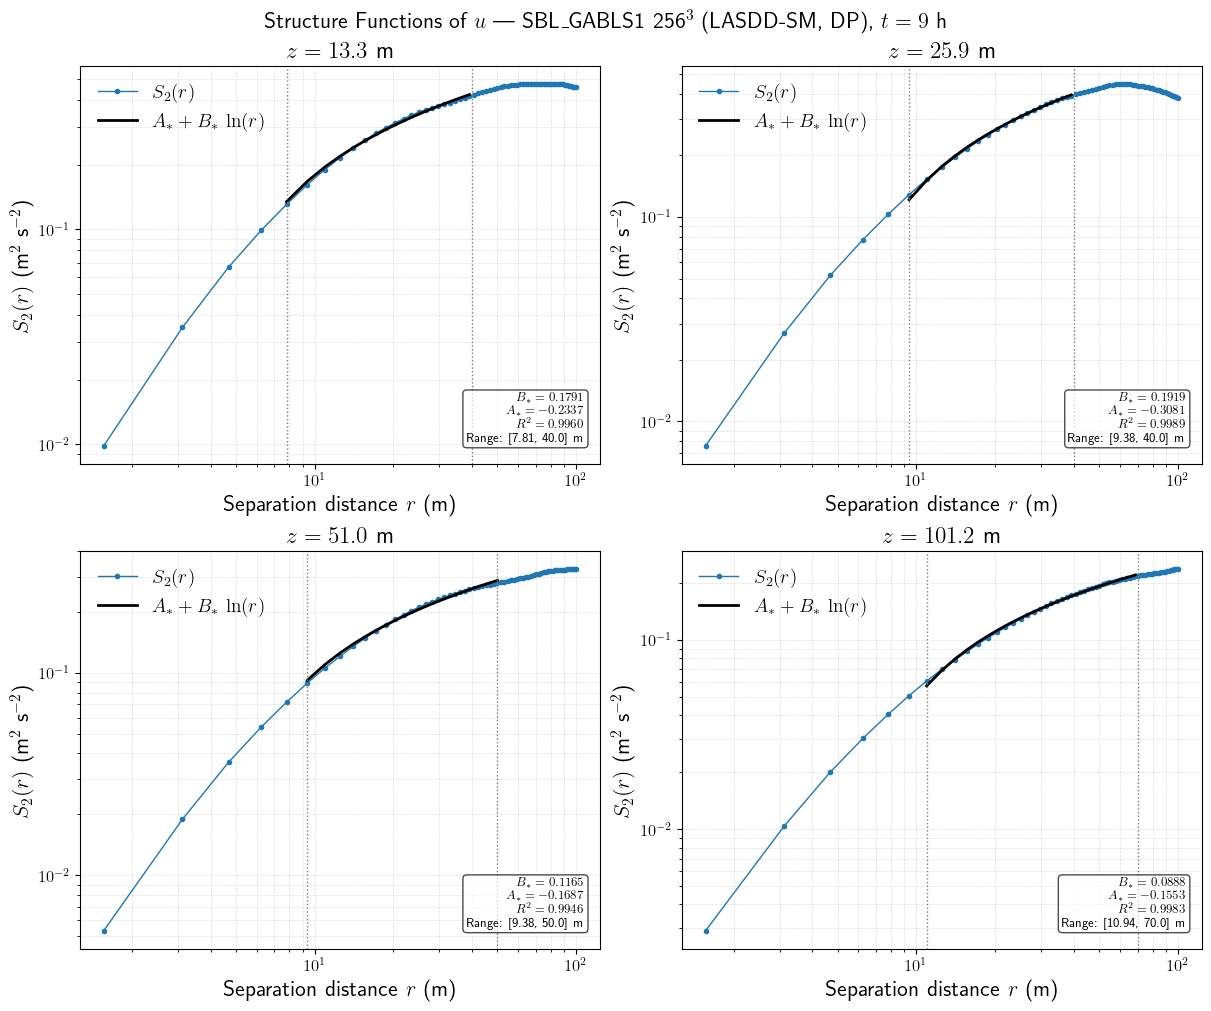

In [105]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.flatten()

max_r = nx // 4
min_r = 1          # start at r = dx

# Fit range per height level [z~13m, z~26m, z~51m, z~101m] — adjust as needed
r_lo_u = [5*dx, 6*dx, 6*dx, 7*dx  ]   # start of fit range (m)
r_hi_u = [40.0, 40.0, 50.0, 70.0]   # end   of fit range (m)

for i, k in enumerate(k_levels):
    S, rr    = StructureFunction1D_LES(u3D[:, :, k], max_r=max_r)
    r_m      = rr * dx
    r_m_plot = r_m[min_r - 1:]
    S2_plot  = S[1, min_r - 1:]

    Bstar, Astar, R2, mask = fit_lnr(r_m_plot, S2_plot, r_lo_u[i], r_hi_u[i])
    S2_fit = Astar + Bstar * np.log(r_m_plot[mask])

    ax = axs[i]
    ax.loglog(r_m_plot, S2_plot, color='tab:blue', marker='o',
              markevery=1, markersize=3, linewidth=1.0, label=r'$S_2(r)$')
    ax.loglog(r_m_plot[mask], S2_fit, 'k-', linewidth=2.0,
              label=r'$A_* + B_*\,\ln(r)$')

    ax.axvline(r_lo_u[i], color='gray', linestyle=':', linewidth=1.0)
    ax.axvline(r_hi_u[i], color='gray', linestyle=':', linewidth=1.0)

    info = (f'$B_*={Bstar:.4f}$\n'
            f'$A_*={Astar:.4f}$\n'
            f'$R^2={R2:.4f}$\n'
            f'Range: [{r_lo_u[i]:.2f}, {r_hi_u[i]:.1f}] m')
    ax.text(0.97, 0.05, info, transform=ax.transAxes, fontsize=9,
            va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    ax.set_title(rf'$z = {z_labels[i]}$ m')
    ax.set_xlabel(r'Separation distance $r$ (m)')
    ax.set_ylabel(r'$S_2(r)$ (m$^2$ s$^{-2}$)')
    ax.legend(frameon=False)
    ax.grid(True, which='both', ls='--', alpha=0.4)

    print(f'u  z={z_labels[i]:6s} m: B*={Bstar:.4f}, A*={Astar:.4f}, R2={R2:.4f}')

fig.suptitle(r'Structure Functions of $u$ — SBL\_GABLS1 256$^3$ (LASDD-SM, DP), $t=9$ h', fontsize=16)
plt.show()

## Structure Functions of $\theta$

TH z=13.3   m: B*=0.0047, A*=-0.0046, R2=0.9970
TH z=25.9   m: B*=0.0043, A*=-0.0050, R2=0.9992
TH z=51.0   m: B*=0.0041, A*=-0.0044, R2=0.9972
TH z=101.2  m: B*=0.0039, A*=-0.0049, R2=0.9996


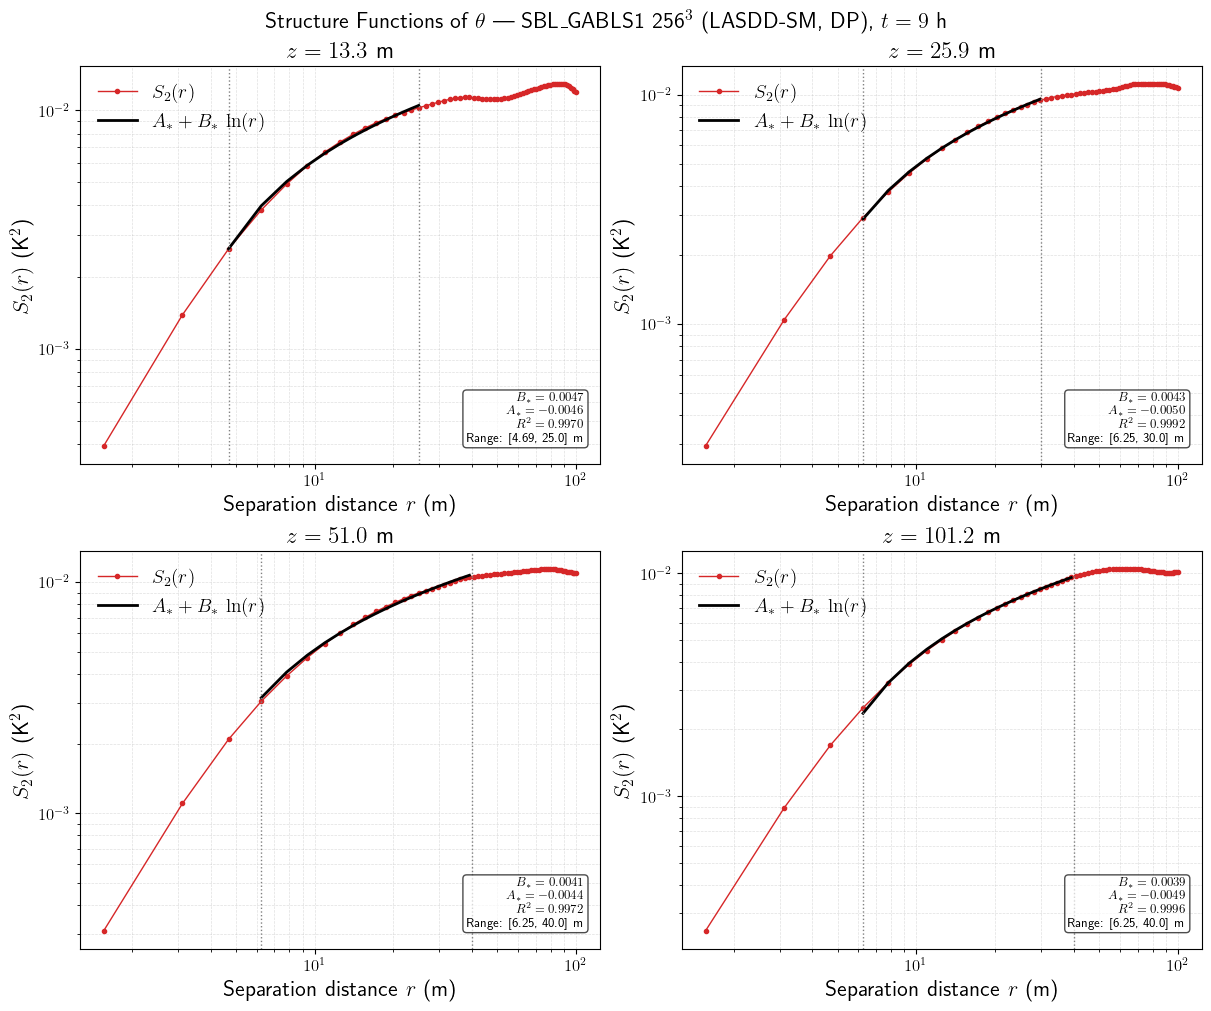

In [106]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.flatten()

max_r = nx // 4
min_r = 1          # start at r = dx

# Fit range per height level [z~13m, z~26m, z~51m, z~101m] — adjust as needed
r_lo_th = [3*dx, 4*dx, 4*dx, 4*dx]   # start of fit range (m)
r_hi_th = [25.0, 30.0, 40.0, 40.0]   # end   of fit range (m)

for i, k in enumerate(k_levels):
    S, rr    = StructureFunction1D_LES(TH3D[:, :, k], max_r=max_r)
    r_m      = rr * dx
    r_m_plot = r_m[min_r - 1:]
    S2_plot  = S[1, min_r - 1:]

    Bstar, Astar, R2, mask = fit_lnr(r_m_plot, S2_plot, r_lo_th[i], r_hi_th[i])
    S2_fit = Astar + Bstar * np.log(r_m_plot[mask])

    ax = axs[i]
    ax.loglog(r_m_plot, S2_plot, color='tab:red', marker='o',
              markevery=1, markersize=3, linewidth=1.0, label=r'$S_2(r)$')
    ax.loglog(r_m_plot[mask], S2_fit, 'k-', linewidth=2.0,
              label=r'$A_* + B_*\,\ln(r)$')

    ax.axvline(r_lo_th[i], color='gray', linestyle=':', linewidth=1.0)
    ax.axvline(r_hi_th[i], color='gray', linestyle=':', linewidth=1.0)

    info = (f'$B_*={Bstar:.4f}$\n'
            f'$A_*={Astar:.4f}$\n'
            f'$R^2={R2:.4f}$\n'
            f'Range: [{r_lo_th[i]:.2f}, {r_hi_th[i]:.1f}] m')
    ax.text(0.97, 0.05, info, transform=ax.transAxes, fontsize=9,
            va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    ax.set_title(rf'$z = {z_labels[i]}$ m')
    ax.set_xlabel(r'Separation distance $r$ (m)')
    ax.set_ylabel(r'$S_2(r)$ (K$^2$)')
    ax.legend(frameon=False)
    ax.grid(True, which='both', ls='--', alpha=0.4)

    print(f'TH z={z_labels[i]:6s} m: B*={Bstar:.4f}, A*={Astar:.4f}, R2={R2:.4f}')

fig.suptitle(r'Structure Functions of $\theta$ — SBL\_GABLS1 256$^3$ (LASDD-SM, DP), $t=9$ h', fontsize=16)
plt.show()